#### Some tests for GPU `tensorflow`

In [1]:
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))


2.10.1
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from tensorflow.python.platform import build_info as tf_build_info
print("CUDA:", tf_build_info.build_info["cuda_version"])
print("cuDNN:", tf_build_info.build_info["cudnn_version"])

CUDA: 64_112
cuDNN: 64_8


In [3]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_virtual_device_configuration( gpus[0], [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=1024)] )
        print("[/] Limited GPU memory to 1 GB.")
    except RuntimeError as e:
        print(e)

[/] Limited GPU memory to 1 GB.


In [4]:
# !pip uninstall tensorflow tensorflow-intel -y
# !pip install tensorflow==2.10.1


In [5]:
#!pip uninstall -y numpy scipy
#!pip install numpy==1.23.5 scipy==1.9.3


In [6]:
#!pip uninstall -y scipy


In [7]:
#!pip install scipy==1.10.1 --no-cache-dir


### Had to re-define `CategoricalFocalLoss` as it was missing in this old version of tensorflow
 - should have the same functionanlity

In [8]:
import tensorflow as tf
from tensorflow.keras.losses import Loss #type:ignore
from tensorflow.keras import backend as K #type:ignore

class CategoricalFocalLoss(Loss):
    """
    Categorical focal loss for one-hot labels.
    Usage:
        loss = CategoricalFocalLoss(gamma=2.0, alpha=0.25)
        model.compile(..., loss=loss, ...)
    """
    def __init__(self, gamma=2.0, alpha=0.25, from_logits=False, reduction=tf.keras.losses.Reduction.AUTO, name="categorical_focal_loss"):
        super().__init__(reduction=reduction, name=name)
        self.gamma = float(gamma)
        self.alpha = float(alpha) if alpha is not None else None
        self.from_logits = from_logits

    def call(self, y_true, y_pred):
        """
        y_true: one-hot (batch, classes)
        y_pred: probabilities (softmax) or logits if from_logits=True
        """
        # If logits provided, convert to probabilities
        if self.from_logits:
            y_pred = tf.nn.softmax(y_pred, axis=-1)

        # Clip to avoid log(0) and NaNs
        eps = K.epsilon()
        y_pred = K.clip(y_pred, eps, 1.0 - eps)

        # Compute cross-entropy per class
        cross_entropy = -y_true * K.log(y_pred)  # shape (batch, classes)

        # get p_t: the model probability for the true class per sample (elementwise y_true * y_pred)
        p_t = y_true * y_pred  # (batch, classes)

        # focal weighting: (1 - p_t)^gamma
        focal_factor = K.pow(1.0 - p_t, self.gamma)

        if self.alpha is not None:
            alpha_factor = y_true * self.alpha + (1.0 - y_true) * (1.0 - self.alpha)
            # For multiclass one-hot alpha factor reduces to alpha for true class; keep simple:
            alpha_factor = y_true * self.alpha  # only apply alpha to true class entries
        else:
            alpha_factor = 1.0

        # elementwise focal loss
        loss = alpha_factor * focal_factor * cross_entropy  # (batch, classes)

        # sum over classes then mean over batch
        loss = K.sum(loss, axis=-1)
        return K.mean(loss)

    def get_config(self):
        return {"gamma": self.gamma, "alpha": self.alpha, "from_logits": self.from_logits}


***
# Normal Code

In [9]:
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import csv

from tensorflow.keras.regularizers import l2 #type:ignore
from tensorflow.keras.optimizers import Adam, RMSprop, SGD #type:ignore
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential #type:ignore
from tensorflow.keras.applications import EfficientNetB3 #type:ignore
from sklearn.utils.class_weight import compute_class_weight
#from tensorflow.keras.losses import CategoricalFocalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint #type:ignore
from tensorflow.keras.preprocessing.image import ImageDataGenerator #type:ignore
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout #type:ignore
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling2D, LeakyReLU, AveragePooling2D #type:ignore
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, confusion_matrix

In [10]:
from pathlib import Path
import os
import shutil
import random

#### Split data into folders

In [11]:
#script_path = os.path.dirname(os.path.abspath(__file__))
script_path = ""
original_folder = os.path.join(script_path, "EuroSAT_RGB")
base_folder = os.path.join(script_path, "EuroSAT_RGB_split")

In [12]:
def split_data():
    train_ratio = 0.7
    val_ratio = 0.15
    random_state = 42
    random.seed(random_state)

    for split in ["train", "validate", "test"]:
        os.makedirs(os.path.join(base_folder, split), exist_ok=True)
    
    for class_name in os.listdir(original_folder):
        class_path = os.path.join(original_folder, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [f for f in os.listdir(class_path) if f.lower().endswith((".jpg", ".png", ".tif"))]
        random.shuffle(images)

        n_total = len(images)
        n_train = int(n_total * train_ratio)
        n_val = int(n_total * val_ratio)

        splits = {
            "train": images[:n_train],
            "validate": images[n_train:n_train + n_val],
            "test": images[n_train + n_val:]
        }

        for split_name, split_images in splits.items():
            split_dir = os.path.join(base_folder, split_name, class_name)
            os.makedirs(split_dir, exist_ok=True)

            for img_name in split_images:
                src = os.path.join(class_path, img_name)
                dst = os.path.join(split_dir, img_name)
                shutil.copy(src, dst)

        print(f"{class_name}: {n_total} images split into train/val/test")

In [13]:
#split_data()


#### split_data() Output:
 - AnnualCrop: 3000 images split into train/val/test
 - Forest: 3000 images split into train/val/test
 - HerbaceousVegetation: 3000 images split into train/val/test
 - Highway: 2500 images split into train/val/test
 - Industrial: 2500 images split into train/val/test
 - Pasture: 2000 images split into train/val/test
 - PermanentCrop: 2500 images split into train/val/test
 - Residential: 3000 images split into train/val/test 
 - River: 2500 images split into train/val/test 
 - SeaLake: 3000 images split into train/val/test


In [14]:
train_dir = os.path.join(base_folder, "train")
val_dir = os.path.join(base_folder, "validate")
test_dir = os.path.join(base_folder, "test")

In [15]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    shuffle=False 
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    shuffle=False 
)

Found 18900 images belonging to 10 classes.
Found 4050 images belonging to 10 classes.
Found 4050 images belonging to 10 classes.


In [16]:
# from IPython.display import display, Javascript
# display(Javascript('google.colab.output.setIframeHeight(0, true, {maxHeight: 30000})'))
# %config InlineBackend.print_figure_kwargs = {'bbox_inches': None}
# import os
# os.environ["TF_CPP_MIN_LOG_LEVEL"] = "1"
# os.environ["TF_FORCE_CONSOLE_LOG"] = "1"

#### Model (`CNN`) compile and trainig

In [17]:
results_file = 'random_search_results.csv'

completed_trials = 0
if os.path.exists(results_file):
    with open(results_file, 'r') as f:
        completed_trials = sum(1 for _ in f) - 1
print(f"Resuming from trial {completed_trials + 1}...")

    
if not os.path.exists(results_file):
    with open(results_file, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([
            'trial',
            'filters',
            'conv_layers',
            'dense_units',
            'dropout',
            'batch_norm',
            'optimizer',
            'lr',
            'accuracy',
            'precision',
            'recall',
            'f1_score',
            'weighted_score'
        ])

Resuming from trial 3...


In [18]:
class_labels = train_generator.classes
class_weight_dict = dict(
    enumerate(
        compute_class_weight('balanced', classes=np.unique(class_labels), y=class_labels)
    )
)
class_labels

array([0, 0, 0, ..., 9, 9, 9])

In [ ]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

num_trials = 80

callbacks = [
    ModelCheckpoint('checkpoints/best_model.h5', monitor='val_loss', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6)
]

        
for k in range(completed_trials, num_trials):
    print(f"\n=== Trial {k+1}/{num_trials} ===")
    
    K.clear_session()
    
    params = { 
        'filters': random.choice([32, 64]),
        'conv_layers': random.choice([2, 3, 4]),
        'dense_units': random.choice([128, 256, 512]),
        'dropout': round(random.uniform(0.3, 0.6), 2),
        'batch_norm': random.choice([True, False]),
        'optimizer': random.choice(['adam', 'rmsprop', 'sgd']),
        'lr': random.choice([1e-4, 5e-4, 1e-3, 5e-3]),
    }

    model = Sequential()
    filters = params['filters']

    for i in range(params['conv_layers']):
        if i == 0:
            model.add(Conv2D(filters, (3,3), activation='relu', input_shape=(64, 64, 3)))
        else:
            model.add(Conv2D(filters, (3,3), activation='relu'))
        model.add(MaxPooling2D(2,2))
        if params['batch_norm']:
            model.add(BatchNormalization())
        filters *= 2  # Double filters each block
        
    model.add(Flatten())
    model.add(Dense(params['dense_units'], activation='relu'))
    model.add(Dropout(params['dropout']))
    model.add(Dense(train_generator.num_classes, activation='softmax'))

    if params['optimizer'] == 'adam':
        opt = Adam(learning_rate=params['lr'])
    elif params['optimizer'] == 'rmsprop':
        opt = RMSprop(learning_rate=params['lr'])
    else:
        opt = SGD(learning_rate=params['lr'], momentum=0.9)

    model.compile(optimizer=opt, loss=CategoricalFocalLoss(gamma=2.0, alpha=0.25, from_logits=False), metrics=['accuracy'])

    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=50,
        callbacks=callbacks,
        class_weight=class_weight_dict,
        verbose=1
    )

    val_generator.reset()
    preds = model.predict(val_generator, verbose=0)
    y_true = val_generator.classes
    y_pred = np.argmax(preds, axis=1)

    acc = np.mean(y_true == y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    weighted_score = acc * precision * recall * f1

    with open(results_file, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([
            k + 1,
            params['filters'],
            params['conv_layers'],
            params['dense_units'],
            params['dropout'],
            params['batch_norm'],
            params['optimizer'],
            params['lr'],
            round(acc, 6),
            round(precision, 6), #type:ignore
            round(recall, 6), #type:ignore
            round(f1, 6), #type:ignore
            round(weighted_score, 6)
        ])

    print(f"[/] Saved trial {k+1}: acc={acc:.4f}, f1={f1:.4f}, weighted={weighted_score:.6f}")


=== Trial 3/80 ===
Epoch 1/50
591/591 [==============================] - ETA: 0s - loss: 0.2970 - accuracy: 0.5825
Epoch 1: val_loss improved from inf to 0.26550, saving model to checkpoints\best_model.h5
591/591 [==============================] - 25s 37ms/step - loss: 0.2970 - accuracy: 0.5825 - val_loss: 0.2655 - val_accuracy: 0.5694 - lr: 1.0000e-04
Epoch 2/50
591/591 [==============================] - ETA: 0s - loss: 0.1816 - accuracy: 0.6986
Epoch 2: val_loss improved from 0.26550 to 0.17534, saving model to checkpoints\best_model.h5
591/591 [==============================] - 22s 37ms/step - loss: 0.1816 - accuracy: 0.6986 - val_loss: 0.1753 - val_accuracy: 0.7301 - lr: 1.0000e-04
Epoch 3/50
591/591 [==============================] - ETA: 0s - loss: 0.1411 - accuracy: 0.7469
Epoch 3: val_loss improved from 0.17534 to 0.13786, saving model to checkpoints\best_model.h5
591/591 [==============================] - 28s 47ms/step - loss: 0.1411 - accuracy: 0.7469 - val_loss: 0.1379 - va

In [ ]:
model.save("SataliteClassification.h5")
#model = tf.keras.models.load_model("SataliteClassification.keras")

In [ ]:
gpus = tf.config.list_physical_devices('GPU')
details = tf.config.experimental.get_memory_info(gpus[0].name[17:])
print(f"GPU: {gpus[0].name}")
print(f"  Used VRAM: {details['current'] / 1024**2:.2f} MB")
print(f"  Peak VRAM: {details['peak'] / 1024**2:.2f} MB")

GPU: /physical_device:GPU:0
  Used VRAM: 257.34 MB
  Peak VRAM: 486.03 MB


#### Model Test

In [ ]:
def evaluate_model(model, test_ds, class_names):
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    print(f"\nTest Results:\nAccuracy: {test_acc:.4f} | Loss: {test_loss:.4f}")

    preds = model.predict(test_ds, verbose=1)
    y_pred = np.argmax(preds, axis=1)

    if hasattr(test_ds, 'labels'):
        y_true = test_ds.labels
    else:
        y_true = np.concatenate([np.argmax(y, axis=1) for _, y in test_ds], axis=0)

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

    print('\nClassification Report:\n')
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    return test_acc, test_loss, y_true, y_pred


Test Results:
Accuracy: 0.3988 | Loss: 0.2912
127/127 [==============================] - 2s 15ms/step


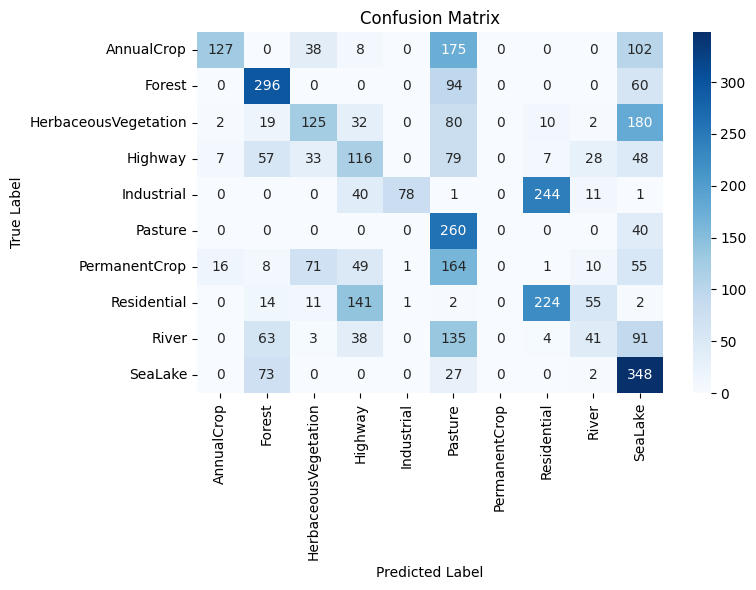


Classification Report:

                      precision    recall  f1-score   support

          AnnualCrop     0.8355    0.2822    0.4219       450
              Forest     0.5585    0.6578    0.6041       450
HerbaceousVegetation     0.4448    0.2778    0.3420       450
             Highway     0.2736    0.3093    0.2904       375
          Industrial     0.9750    0.2080    0.3429       375
             Pasture     0.2557    0.8667    0.3948       300
       PermanentCrop     0.0000    0.0000    0.0000       375
         Residential     0.4571    0.4978    0.4766       450
               River     0.2752    0.1093    0.1565       375
             SeaLake     0.3754    0.7733    0.5054       450

            accuracy                         0.3988      4050
           macro avg     0.4451    0.3982    0.3535      4050
        weighted avg     0.4568    0.3988    0.3635      4050

Test Accuracy: 0.3988
Test Loss: 0.2912


c:\Users\S1NdBAD\anaconda3\envs\tf_gpu\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\S1NdBAD\anaconda3\envs\tf_gpu\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\S1NdBAD\anaconda3\envs\tf_gpu\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
test_acc, test_loss, y_true, y_pred = evaluate_model(model, test_generator, list(test_generator.class_indices.keys()))
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

In [ ]:
def plot_training_curves(model, test_acc=0):
    acc = model.history['accuracy']
    val_acc = model.history['val_accuracy']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    plt.plot(epochs_range, acc, label='Train Acc')
    plt.plot(epochs_range, val_acc, label='Val Acc')
    plt.axhline(y=test_acc, linestyle='--', color='green', label=f'Test Acc: {test_acc:.2f}')
    plt.title('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

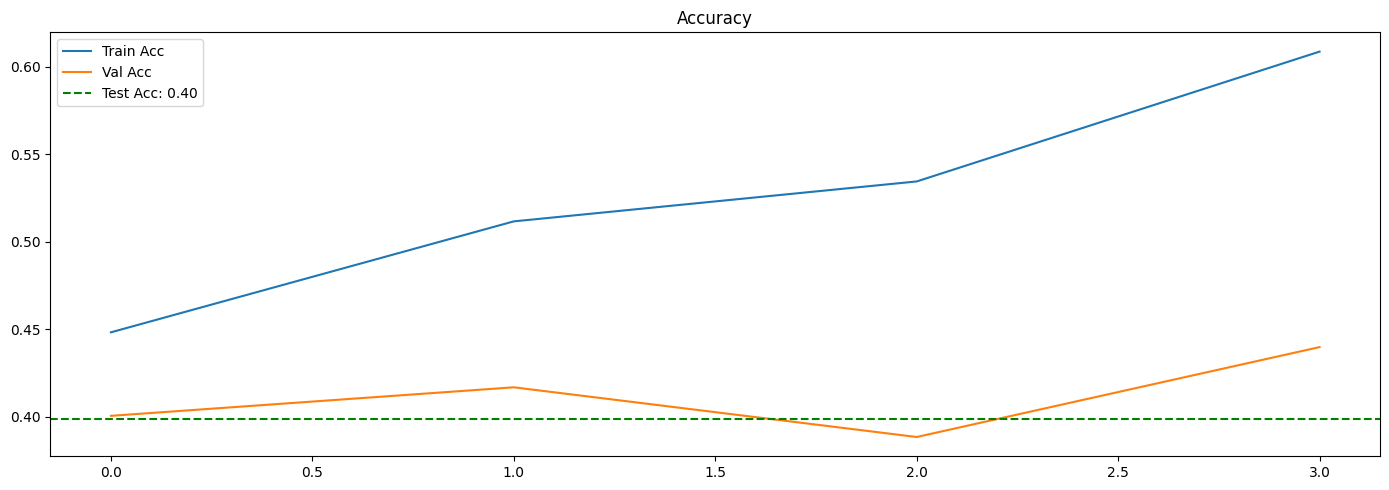

In [ ]:
plot_training_curves(history, test_acc=test_acc)

1/1 [==============================] - 0s 22ms/step


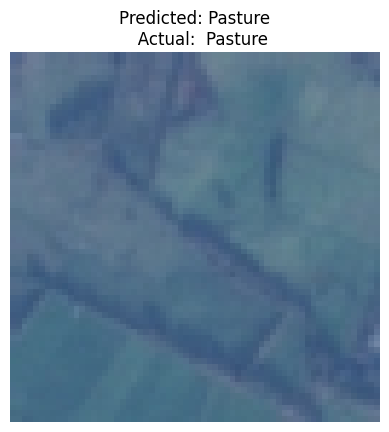


Model prediction: Pasture


In [ ]:
split_dir = r"D:\Coding\Jupyter\DEPI\DEPI-Final-Project\Dataset\Project 6 Datasets\EuroSAT_RGB_split\test"
img_size = (64, 64)
class_names = list(test_generator.class_indices.keys())

all_image_paths = []
for class_dir in os.listdir(split_dir):
    class_path = os.path.join(split_dir, class_dir)
    if os.path.isdir(class_path):
        for fname in os.listdir(class_path):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                all_image_paths.append(os.path.join(class_path, fname))

random_image_path = random.choice(all_image_paths)
image_type = random_image_path.split("\\")[-1].split("_")[0]

img = cv2.imread(random_image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) #type: ignore
img_resized = cv2.resize(img, img_size)
img_array = np.expand_dims(img_resized, axis=0) / 255.0  # normalize

pred = model.predict(img_array)
pred_class = class_names[np.argmax(pred)]

plt.imshow(img)
plt.title(f"Predicted: {pred_class}\n   Actual:  {image_type}")
plt.axis('off')
plt.show()

***
#### Read `random_search_results.csv` file

In [ ]:
import pandas as pd

df = pd.read_csv(results_file)
df_sorted = df.sort_values(by='weighted_score', ascending=False)
df_sorted.reset_index(drop=True, inplace=True)
df_sorted

,trial,filters,conv_layers,dense_units,dropout,batch_norm,optimizer,lr,accuracy,precision,recall,f1_score,weighted_score
0,47,256,3,128,0.53,True,adam,0.0005,0.920741,0.921338,0.920741,0.920345,0.718860
1,14,128,3,512,0.38,False,rmsprop,0.0010,0.909630,0.910395,0.909630,0.909622,0.685204
2,52,64,3,256,0.23,False,rmsprop,0.0010,0.908148,0.909171,0.908148,0.907911,0.680773
3,41,128,3,128,0.27,True,adam,0.0005,0.906420,0.908841,0.906420,0.905555,0.676179
4,73,32,3,128,0.52,True,rmsprop,0.0005,0.899012,0.901705,0.899012,0.898594,0.654876
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,22,64,3,256,0.48,True,adam,0.0050,0.172099,0.036306,0.172099,0.059723,0.000064
76,10,32,2,512,0.21,True,adam,0.0050,0.171358,0.035302,0.171358,0.057845,0.000060
77,37,128,3,512,0.37,True,rmsprop,0.0050,0.153333,0.034544,0.153333,0.056359,0.000046
78,6,32,1,512,0.44,False,rmsprop,0.0050,0.111111,0.012346,0.111111,0.022222,0.000003
